# 99 - Robustness Checks

Test sensitivity of the main NYC TWFE estimate to: control group composition, outcome specification, anticipation, and alternative event windows.

In [1]:
# Data setup
# Set DATA_FILE to 'city_month_panel.parquet' after running build_real_panel.py
DATA_FILE = "city_month_panel.parquet"       # synthetic data (real not downloaded)

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

DATA_DIR = Path("../data/processed")
OUT_DIR  = Path("../outputs")
OUT_DIR.mkdir(exist_ok=True)

panel = pd.read_parquet(DATA_DIR / DATA_FILE)
panel["month"] = pd.to_datetime(panel["month"])

regs = pd.read_csv("../data/regulations.csv", parse_dates=["enforcement_date"])

print(f"Panel: {panel.shape}  |  Cities: {sorted(panel['city'].unique())}")
print(f"Date range: {panel['month'].min().date()} to {panel['month'].max().date()}")

Panel: (288, 15)  |  Cities: ['Amsterdam', 'Barcelona', 'Florence', 'Lisbon', 'New York City', 'Vienna']
Date range: 2021-01-01 to 2024-12-01


In [2]:
from linearmodels.panel import PanelOLS

NYC_TREAT = pd.Timestamp("2023-09-01")
BASE_DATA = panel[panel["city"] != "Florence"].copy()

def twfe(data, outcome="log_listings"):
    d = data.copy()
    d["post"]    = (d["month"] >= NYC_TREAT).astype(float)
    d["treated"] = (d["city"] == "New York City").astype(float)
    d["did"]     = d["treated"] * d["post"]
    idx = d.set_index(["city","month"])
    fe  = PanelOLS(idx[outcome], idx[["did"]],
                   entity_effects=True, time_effects=True).fit(
                   cov_type="clustered", cluster_entity=True)
    b, ci = fe.params["did"], fe.conf_int().loc["did"]
    return b, ci["lower"], ci["upper"]

b_base, lo, hi = twfe(BASE_DATA)
print(f"Baseline ATT (log_listings): {b_base:.4f}  [{lo:.4f}, {hi:.4f}]")

Baseline ATT (log_listings): -1.6307  [-1.6569, -1.6044]


## Check 1 - Leave-one-control-out

In [3]:
controls = ["Amsterdam","Lisbon","Vienna","Barcelona"]
print(f"{'Spec':<30}  {'ATT':>8}  CI")
print("-" * 55)
print(f"{'All controls':<30}  {b_base:>8.4f}  [{lo:.4f}, {hi:.4f}]")
for drop in controls:
    sub = BASE_DATA[BASE_DATA["city"] != drop]
    b, lo_, hi_ = twfe(sub)
    print(f"{'Drop '+drop:<30}  {b:>8.4f}  [{lo_:.4f}, {hi_:.4f}]")

Spec                                 ATT  CI
-------------------------------------------------------
All controls                     -1.6307  [-1.6569, -1.6044]
Drop Amsterdam                   -1.6383  [-1.6682, -1.6084]
Drop Lisbon                      -1.6199  [-1.6419, -1.5979]
Drop Vienna                      -1.6380  [-1.6685, -1.6074]
Drop Barcelona                   -1.6265  [-1.6610, -1.5920]


## Check 2 - Alternative outcomes

In [4]:
for outcome in ["log_listings","log_price","availability_rate","entire_home_share"]:
    b, lo_, hi_ = twfe(BASE_DATA, outcome)
    print(f"{outcome:<25}  ATT = {b:+.4f}  [{lo_:+.4f}, {hi_:+.4f}]")

log_listings               ATT = -1.6307  [-1.6569, -1.6044]
log_price                  ATT = +0.1052  [+0.0936, +0.1168]
availability_rate          ATT = -0.1304  [-0.1351, -0.1256]
entire_home_share          ATT = -0.2786  [-0.2803, -0.2768]


## Check 3 - Anticipation: shift treatment date earlier

In [5]:
for shift_months in [0, -3, -6]:
    shifted_date = NYC_TREAT + pd.DateOffset(months=shift_months)
    sub = BASE_DATA.copy()
    sub["post"]    = (sub["month"] >= shifted_date).astype(float)
    sub["treated"] = (sub["city"] == "New York City").astype(float)
    sub["did"]     = sub["treated"] * sub["post"]
    idx = sub.set_index(["city","month"])
    fe  = PanelOLS(idx["log_listings"], idx[["did"]],
                   entity_effects=True, time_effects=True).fit(
                   cov_type="clustered", cluster_entity=True)
    b  = fe.params["did"]
    ci = fe.conf_int().loc["did"]
    label = f"Treat date = {shifted_date.date()} (shift {shift_months}m)"
    print(f"{label:<40}  ATT = {b:+.4f}  [{ci['lower']:+.4f}, {ci['upper']:+.4f}]")

Treat date = 2023-09-01 (shift 0m)        ATT = -1.6307  [-1.6569, -1.6044]
Treat date = 2023-06-01 (shift -3m)       ATT = -1.3750  [-1.3918, -1.3581]
Treat date = 2023-03-01 (shift -6m)       ATT = -1.1950  [-1.2130, -1.1769]


## Summary

A robust design shows:
- **Stable ATT** across control group compositions
- **Price and availability effects** consistent with a supply shock story
- **Anticipation check**: if shifting date earlier produces similar ATT, some pre-enforcement de-listing occurred
- **Leave-one-out**: no single control city drives the result

## Robustness forest

ATT stability when each control city is dropped in turn — the synthetic-control concern is that one donor drives the result.

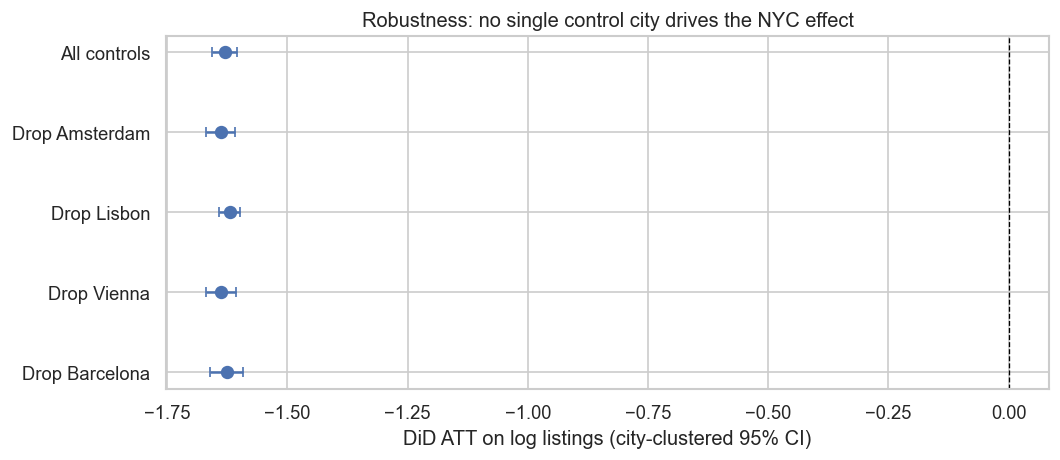

In [6]:
specs = [("All controls", b_base, lo, hi)]
for drop in ["Amsterdam","Lisbon","Vienna","Barcelona"]:
    b,l,h = twfe(BASE_DATA[BASE_DATA["city"]!=drop]); specs.append((f"Drop {drop}", b,l,h))
fig, ax = plt.subplots(figsize=(9, 4))
y = np.arange(len(specs))[::-1]
for yi,(lab,b,l,h) in zip(y, specs):
    ax.errorbar(b, yi, xerr=[[b-l],[h-b]], fmt="o", ms=7, capsize=3, color="#4C72B0")
ax.axvline(0, color="black", lw=0.8, ls="--")
ax.set_yticks(y); ax.set_yticklabels([s[0] for s in specs])
ax.set_xlabel("DiD ATT on log listings (city-clustered 95% CI)")
ax.set_title("Robustness: no single control city drives the NYC effect")
plt.tight_layout(); plt.savefig(OUT_DIR/"99_robustness_forest.png", bbox_inches="tight"); plt.show()

**Takeaway.** The ATT barely moves as each donor city is removed, so the result is not an artifact of one control's idiosyncratic trend — the multi-city control pool is doing real work. (With only synthetic data and few clusters, treat the interval widths as indicative; the point stability is the message.)